# GeoWatch Week 2 — EDA and Classical Baselines

**Objective:** establish transparent non-deep-learning
change-detection baselines before training the Siamese U-Net.

**Quantitative dataset:** OSCD only.

**Custom Hyderabad AOI:** qualitative demonstration only;
it is not used in any metric calculation.

**Official OSCD split:** 14 training regions and 10 testing
regions.

## Evaluation protocol

The positive change class is evaluated using precision,
recall, F1 and Intersection over Union.

Overall pixel accuracy is not used as the headline metric.
OSCD is highly imbalanced, so predicting unchanged for most
pixels can produce apparently high accuracy while missing
real change.

Baseline fitting rules:

- Otsu threshold: fitted from OSCD training imagery only.
- StandardScaler, PCA and K-Means: fitted from OSCD training
  imagery only.
- Test imagery and labels are excluded from fitting.
- Ground-truth labels are used only for quantitative
  evaluation.

In [1]:
from pathlib import Path
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import Markdown, display


ROOT = Path.cwd()

if not (ROOT / "reports").is_dir():
    ROOT = ROOT.parent

assert (ROOT / "reports").is_dir(), (
    "Run this notebook from the repository root "
    "or from the notebooks directory."
)

EDA_DIR = ROOT / "reports/week2/eda"
OTSU_DIR = (
    ROOT
    / "reports/week2/baselines/band_diff_otsu"
)
CVA_DIR = (
    ROOT
    / "reports/week2/baselines/cva_pca_kmeans"
)

eda = json.loads(
    (
        EDA_DIR
        / "oscd_dataset_statistics.json"
    ).read_text(encoding="utf-8")
)
otsu = json.loads(
    (
        OTSU_DIR
        / "band_diff_otsu_report.json"
    ).read_text(encoding="utf-8")
)
cva = json.loads(
    (
        CVA_DIR
        / "cva_pca_kmeans_report.json"
    ).read_text(encoding="utf-8")
)

print("Week 2 artifacts loaded")
print("Repository root:", ROOT)

Week 2 artifacts loaded
Repository root: C:\Ml project\Geo-Watch\geowatch


## OSCD dataset characteristics

In [2]:
dataset_table = '''
| Split | Regions | Change pixels | Unchanged:change |
|---|---:|---:|---:|
| Train | 14 | 2.2976% | 42.52:1 |
| Test | 10 | 5.1683% | 18.35:1 |
| Overall | 24 | 3.2184% | 30.07:1 |
'''

display(Markdown(dataset_table))

print(
    "Only",
    f"3.22%",
    "of evaluated OSCD pixels belong to the change class."
)


| Split | Regions | Change pixels | Unchanged:change |
|---|---:|---:|---:|
| Train | 14 | 2.2976% | 42.52:1 |
| Test | 10 | 5.1683% | 18.35:1 |
| Overall | 24 | 3.2184% | 30.07:1 |


Only 3.22% of evaluated OSCD pixels belong to the change class.


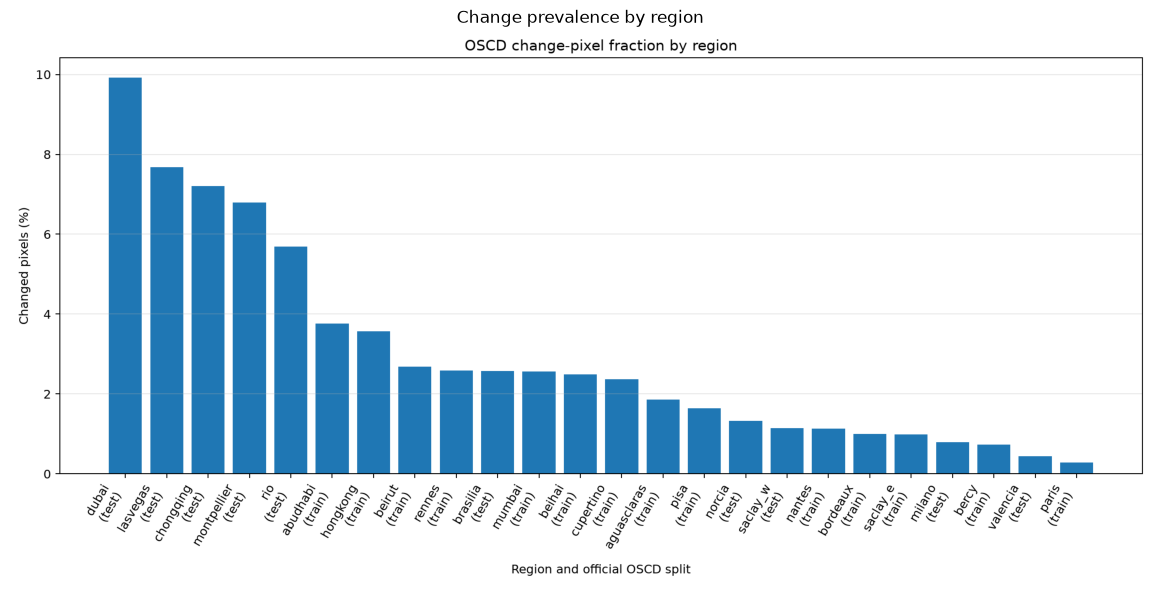

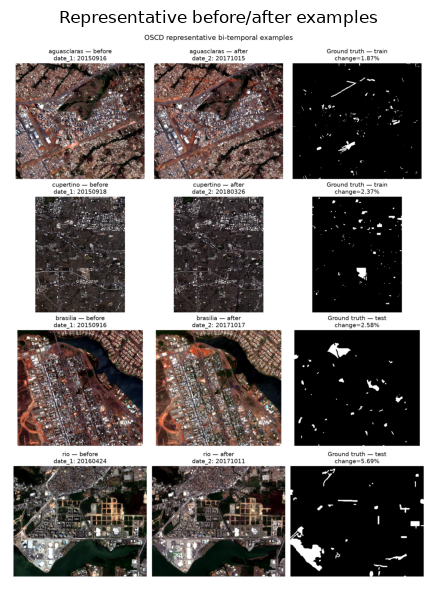

In [3]:
figure_paths = [
    (
        EDA_DIR
        / "oscd_change_fraction_by_region.png",
        "Change prevalence by region",
    ),
    (
        EDA_DIR
        / "oscd_representative_examples.png",
        "Representative before/after examples",
    ),
]

for figure_path, title in figure_paths:
    assert figure_path.is_file(), figure_path

    image = np.asarray(
        Image.open(figure_path).convert("RGB")
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Classical baseline results

In [4]:
result_table = '''
| Baseline | Precision | Recall | F1 | IoU | Accuracy* |
|---|---:|---:|---:|---:|---:|
| Band Difference + Otsu | 0.115846 | 0.513713 | 0.189058 | 0.104398 | 0.772232 |
| CVA + PCA + K-Means | 0.060915 | 0.669217 | 0.111665 | 0.059134 | 0.449695 |
'''

display(Markdown(result_table))
display(
    Markdown(
        "\\*Accuracy is a secondary diagnostic because "
        "unchanged pixels dominate OSCD."
    )
)


| Baseline | Precision | Recall | F1 | IoU | Accuracy* |
|---|---:|---:|---:|---:|---:|
| Band Difference + Otsu | 0.115846 | 0.513713 | 0.189058 | 0.104398 | 0.772232 |
| CVA + PCA + K-Means | 0.060915 | 0.669217 | 0.111665 | 0.059134 | 0.449695 |


\*Accuracy is a secondary diagnostic because unchanged pixels dominate OSCD.

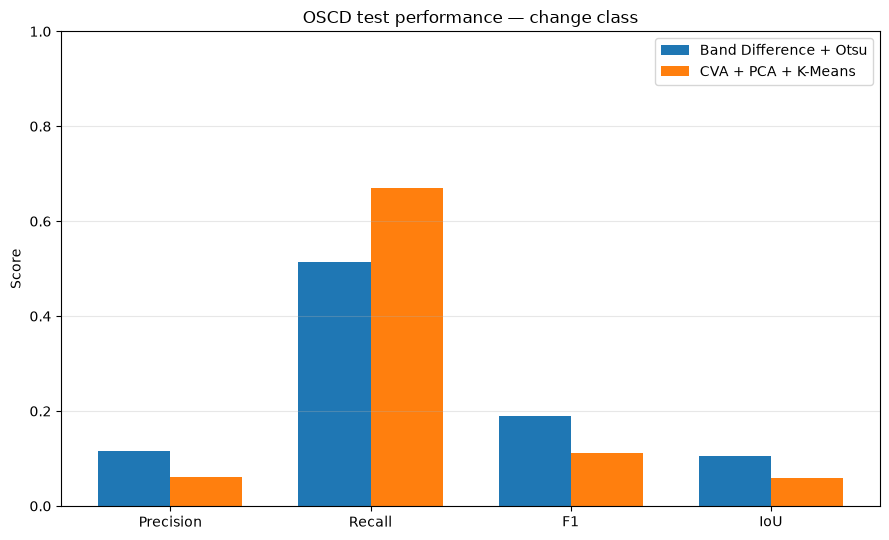

In [5]:
metric_names = [
    "precision",
    "recall",
    "f1_score",
    "iou",
]

display_names = [
    "Precision",
    "Recall",
    "F1",
    "IoU",
]

otsu_values = [
    otsu["test_metrics"][metric]
    for metric in metric_names
]
cva_values = [
    cva["test_metrics"][metric]
    for metric in metric_names
]

positions = np.arange(
    len(metric_names)
)
width = 0.36

plt.figure(figsize=(9, 5.5))
plt.bar(
    positions - width / 2,
    otsu_values,
    width,
    label="Band Difference + Otsu",
)
plt.bar(
    positions + width / 2,
    cva_values,
    width,
    label="CVA + PCA + K-Means",
)
plt.xticks(
    positions,
    display_names,
)
plt.ylim(0.0, 1.0)
plt.ylabel("Score")
plt.title(
    "OSCD test performance — change class"
)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()
plt.show()

## Qualitative comparison

The example below is **rio**, selected
deterministically as the median-F1 Otsu test region. It is
not manually selected as a best-looking result.

Difference and magnitude images are diagnostic intensity
maps. Binary predictions are compared with the OSCD
ground-truth mask.

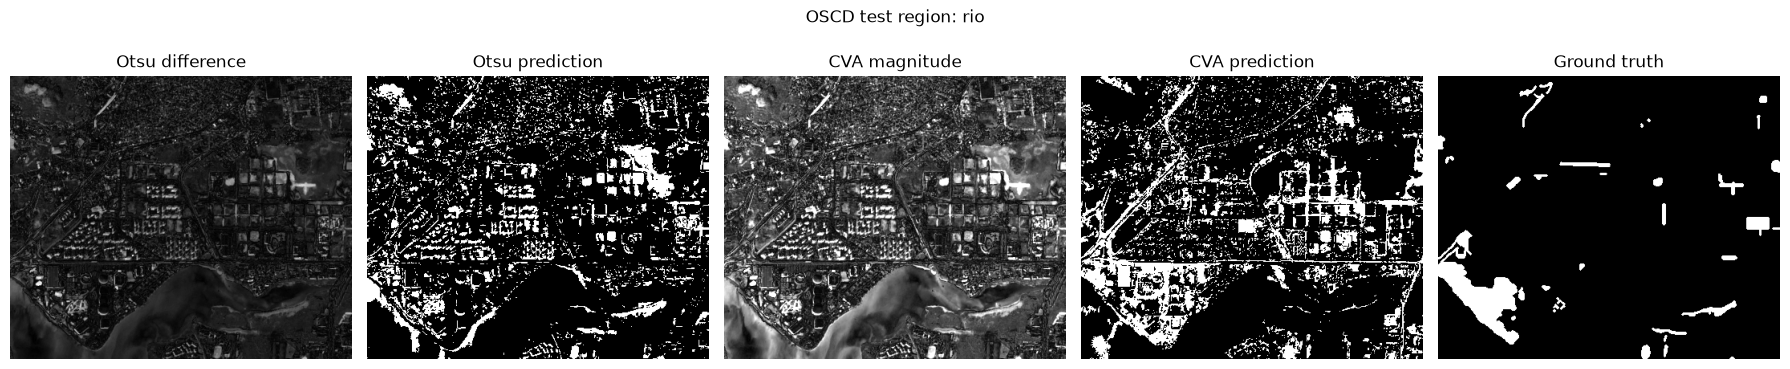

In [6]:
region = "rio"

otsu_preview_path = (
    OTSU_DIR
    / "difference_previews/test"
    / f"{region}.png"
)
otsu_prediction_path = (
    OTSU_DIR
    / "predictions/test"
    / f"{region}.png"
)
cva_preview_path = (
    CVA_DIR
    / "magnitude_previews/test"
    / f"{region}.png"
)
cva_prediction_path = (
    CVA_DIR
    / "predictions/test"
    / f"{region}.png"
)

with (
    EDA_DIR
    / "oscd_region_statistics.csv"
).open(
    "r",
    encoding="utf-8-sig",
    newline="",
) as file:
    eda_rows = list(
        csv.DictReader(file)
    )

region_row = next(
    row
    for row in eda_rows
    if row["region"] == region
    and row["split"] == "test"
)

ground_truth_path = Path(
    region_row["label_path"]
)

if not ground_truth_path.is_absolute():
    ground_truth_path = (
        ROOT / ground_truth_path
    )

paths = [
    otsu_preview_path,
    otsu_prediction_path,
    cva_preview_path,
    cva_prediction_path,
    ground_truth_path,
]

for path in paths:
    assert path.is_file(), path

otsu_preview = np.asarray(
    Image.open(
        otsu_preview_path
    ).convert("L")
)
otsu_prediction = np.asarray(
    Image.open(
        otsu_prediction_path
    ).convert("L")
)
cva_preview = np.asarray(
    Image.open(
        cva_preview_path
    ).convert("L")
)
cva_prediction = np.asarray(
    Image.open(
        cva_prediction_path
    ).convert("L")
)
ground_truth = (
    np.asarray(
        Image.open(
            ground_truth_path
        ).convert("L")
    )
    > 0
)

images = [
    otsu_preview,
    otsu_prediction,
    cva_preview,
    cva_prediction,
    ground_truth,
]
titles = [
    "Otsu difference",
    "Otsu prediction",
    "CVA magnitude",
    "CVA prediction",
    "Ground truth",
]

figure, axes = plt.subplots(
    1,
    5,
    figsize=(18, 4),
)

for axis, image, title in zip(
    axes,
    images,
    titles,
):
    axis.imshow(
        image,
        cmap="gray",
    )
    axis.set_title(title)
    axis.axis("off")

figure.suptitle(
    f"OSCD test region: {region}"
)
figure.tight_layout()
plt.show()

## Interpretation

**Band Difference + Otsu** is the stronger classical
baseline.

- Test F1: **0.189058**
- Test IoU: **0.104398**
- Relative F1 improvement over CVA: **69.31%**
- Relative IoU improvement over CVA: **76.54%**

CVA + PCA + K-Means obtained higher recall
(0.669217) but much lower precision
(0.060915). It frequently grouped
radiometric or seasonal variation with true land-cover
change.

Neither baseline learns spatial context, object boundaries
or semantic land-use patterns. These limitations justify
moving to a Siamese segmentation architecture.

## Week 3 target

The Siamese U-Net must outperform the strongest frozen
classical baseline:

- **Target F1 greater than 0.189058**
- **Target IoU greater than 0.104398**

It should also produce more spatially coherent masks with
fewer radiometric and seasonal false positives.

In [7]:
assert eda["region_counts"] == {
    "train": 14,
    "test": 10,
    "overall": 24,
}

assert (
    eda[
        "custom_hyderabad_aoi_used_for_metrics"
    ]
    is False
)

assert (
    otsu["test_metrics"]["f1_score"]
    == 0.18905835198584145
)

assert (
    cva["test_metrics"]["f1_score"]
    == 0.11166523401217905
)

assert (
    otsu["test_metrics"]["f1_score"]
    > cva["test_metrics"]["f1_score"]
)

print("Week 2 notebook validation passed")
print(
    "Strongest baseline:",
    "Band Difference + Otsu",
)
print(
    "Week 3 target F1:",
    0.18905835198584145,
)
print(
    "Week 3 target IoU:",
    0.10439781546421385,
)

Week 2 notebook validation passed
Strongest baseline: Band Difference + Otsu
Week 3 target F1: 0.18905835198584145
Week 3 target IoU: 0.10439781546421385
